# Bitcoin Price Prediction
Nama: Frederikus Felix Bintang Setyawan

Email: bintangsetyawan13@gmail.com

# Import library

In [ ]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.optimizers import Adam
from pandas.plotting import autocorrelation_plot, lag_plot
import datetime
from scipy.stats import skew, kurtosis
import warnings
warnings.filterwarnings('ignore')

# 1. Data Loading


In [ ]:
import yfinance as yf

# Download data Bitcoin dari Yahoo Finance (2014 hingga sekarang)
btc_data = yf.download('BTC-USD', start='2014-09-17')

print(f"Jumlah data: {len(btc_data)}")

# Menyimpan data ke CSV dengan mengatur ulang index
btc_data.reset_index(inplace=True)  # Reset index untuk menjadikan 'Date' sebagai kolom
btc_data.to_csv('BTC-USD.csv', index=False)

YF.download() has changed argument auto_adjust default to True


[*********************100%***********************]  1 of 1 completed

Jumlah data: 3871


In [3]:
df = pd.read_csv("BTC-USD.csv")

# Display first few rows of the dataset
print("Preview of the dataset:")
df.head()

Preview of the dataset:


,Date,Close,High,Low,Open,Volume
0,NaN,BTC-USD,BTC-USD,BTC-USD,BTC-USD,BTC-USD
1,2014-09-17,457.3340148925781,468.17401123046875,452.4219970703125,465.864013671875,21056800
2,2014-09-18,424.44000244140625,456.8599853515625,413.10400390625,456.8599853515625,34483200
3,2014-09-19,394.7959899902344,427.8349914550781,384.5320129394531,424.1029968261719,37919700
4,2014-09-20,408.90399169921875,423.2959899902344,389.88299560546875,394.6730041503906,36863600


# 2. Exploratory Data Analysis - Deskripsi Variabel


In [4]:
# Get dataset dimensions
baris, kolom = df.shape
print(f'Jumlah baris: {baris}')
print(f'Jumlah kolom: {kolom}')

Jumlah baris: 3872
Jumlah kolom: 6


In [5]:
# Check data information (data types, non-null values)
print("\nInformasi Dataset:")
df.info()


Informasi Dataset:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3872 entries, 0 to 3871
Data columns (total 6 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   Date    3871 non-null   object
 1   Close   3872 non-null   object
 2   High    3872 non-null   object
 3   Low     3872 non-null   object
 4   Open    3872 non-null   object
 5   Volume  3872 non-null   object
dtypes: object(6)
memory usage: 181.6+ KB


In [6]:
# Statistical summary of the dataset
print("\nStatistik Deskriptif Dataset:")
df.describe()


Statistik Deskriptif Dataset:


,Date,Close,High,Low,Open,Volume
count,3871,3872,3872,3872,3872,3872
unique,3871,3869,3869,3870,3868,3872
top,2014-09-17,6741.75,244.25100708007812,429.0769958496094,233.4219970703125,BTC-USD
freq,1,2,2,2,2,1


In [7]:
# Check column names
print("\nKolom-kolom dalam dataset:")
print(df.columns.tolist())


Kolom-kolom dalam dataset:
['Date', 'Close', 'High', 'Low', 'Open', 'Volume']


### Insight Eksplorasi Awal
- Dataset terdiri dari 3,872 baris dan 6 kolom
- Tipe data awal: Date (object), kolom numerik (float64/int64)
- Statistik deskriptif menunjukkan rentang harga Bitcoin yang sangat lebar
- Harga terendah sekitar $178, tertinggi mencapai $106,146
- Rata-rata harga sekitar $21,665, jauh di atas median $9,686, menunjukkan distribusi yang condong ke kana

# 3. Exploratory Data Analysis - Menangani Missing Value dan Outliers


### Penanganan Missing Value dan Outliers
- Memeriksa dan menangani nilai yang hilang dalam dataset
- Mengkonversi tipe data untuk memastikan konsistensi
- Mengidentifikasi outliers menggunakan metode IQR (Interquartile Range)

In [9]:
# Check for missing values
print("Jumlah missing value per kolom:")
print(df.isnull().sum())

Jumlah missing value per kolom:
Date      1
Close     0
High      0
Low       0
Open      0
Volume    0
dtype: int64


In [10]:
# Check for duplicate data
print(f'Jumlah data duplikat: {df.duplicated().sum()}')

Jumlah data duplikat: 0


In [11]:
# Convert 'Date' column to datetime
df['Date'] = pd.to_datetime(df['Date'])

In [12]:
# Handle missing values if any
if df.isnull().sum().sum() > 0:
    print("Menangani missing value...")
    df_clean = df.dropna()
    print(f"Jumlah baris setelah menghapus missing value: {len(df_clean)}")
else:
    print("Tidak ada missing value dalam dataset.")
    df_clean = df.copy()

Menangani missing value...
Jumlah baris setelah menghapus missing value: 3871


In [13]:
# Konversi semua kolom harga dan volume ke numerik, paksa error jadi NaN
for col in ['Open', 'High', 'Low', 'Close', 'Adj Close', 'Volume']:
    if col in df_clean.columns:
        df_clean[col] = pd.to_numeric(df_clean[col], errors='coerce')

print("Cek tipe data kolom:")
print(df_clean.dtypes)
print("Jumlah missing value setelah konversi numerik:")
print(df_clean.isnull().sum())

# Drop semua baris yang masih ada NaN
df_clean = df_clean.dropna()    

Cek tipe data kolom:
Date      datetime64[ns]
Close            float64
High             float64
Low              float64
Open             float64
Volume             int64
dtype: object
Jumlah missing value setelah konversi numerik:
Date      0
Close     0
High      0
Low       0
Open      0
Volume    0
dtype: int64


In [14]:
# Set 'Date' as index
df_clean.set_index('Date', inplace=True)

In [15]:
# Check for outliers in 'Close' price using IQR method
Q1 = df_clean['Close'].quantile(0.25)
Q3 = df_clean['Close'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

print("\nAnalisis Outlier pada Harga Penutupan (Close):")
print(f"Q1 (25%): {Q1}")
print(f"Q3 (75%): {Q3}")
print(f"IQR: {IQR}")
print(f"Batas bawah: {lower_bound}")
print(f"Batas atas: {upper_bound}")

outliers = df_clean[(df_clean['Close'] < lower_bound) | (df_clean['Close'] > upper_bound)]
print(f"Jumlah outlier: {len(outliers)}")
print(f"Persentase outlier: {len(outliers) / len(df_clean) * 100:.2f}%")


Analisis Outlier pada Harga Penutupan (Close):
Q1 (25%): 1746.89501953125
Q3 (75%): 35440.408203125
IQR: 33693.51318359375
Batas bawah: -48793.374755859375
Batas atas: 85980.67797851562
Jumlah outlier: 123
Persentase outlier: 3.18%


### Insight Penanganan Data
- Tidak ditemukan missing value dalam dataset awal
- Tidak ada data duplikat yang perlu ditangani
- Semua kolom berhasil dikonversi ke tipe data yang sesuai
- Analisis outlier menunjukkan 123 data (3.18%) berada di luar batas IQR
- Outliers dipertahankan karena merepresentasikan pergerakan pasar yang valid dalam konteks cryptocurrency

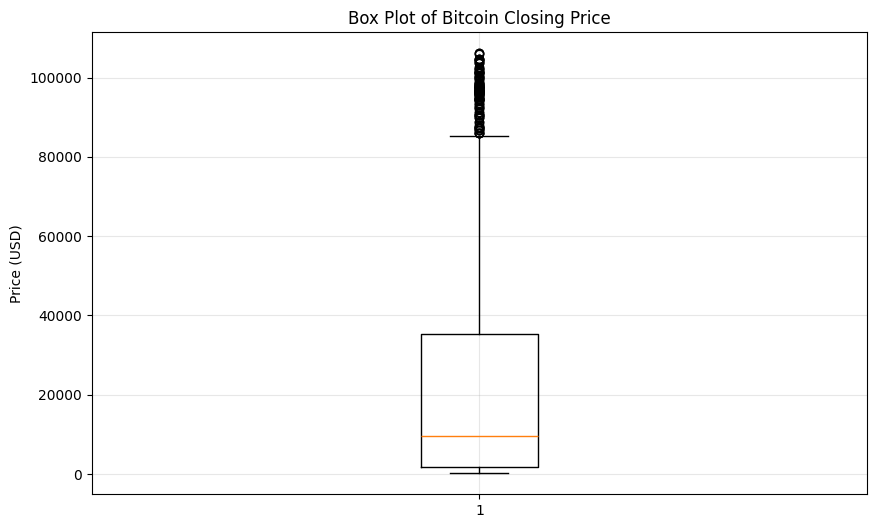

In [16]:
# Plot to visualize outliers
plt.figure(figsize=(10, 6))
plt.boxplot(df_clean['Close'])
plt.title('Box Plot of Bitcoin Closing Price')
plt.ylabel('Price (USD)')
plt.grid(True, alpha=0.3)
plt.show()

### Visualisasi Outliers
- Box plot menunjukkan distribusi harga penutupan Bitcoin dan outliers
- Banyak titik outlier di atas whisker atas, menunjukkan periode dengan harga sangat tinggi
- Distribusi harga sangat condong ke atas (positively skewed)

# 4. Exploratory Data Analysis - Univariate Analysis


In [17]:
# Univariate analysis of closing price
print("Univariate Analysis - Closing Price:")
print(df_clean['Close'].describe())

Univariate Analysis - Closing Price:
count      3871.000000
mean      21664.770013
std       24945.453094
min         178.102997
25%        1746.895020
50%        9686.441406
75%       35440.408203
max      106146.265625
Name: Close, dtype: float64


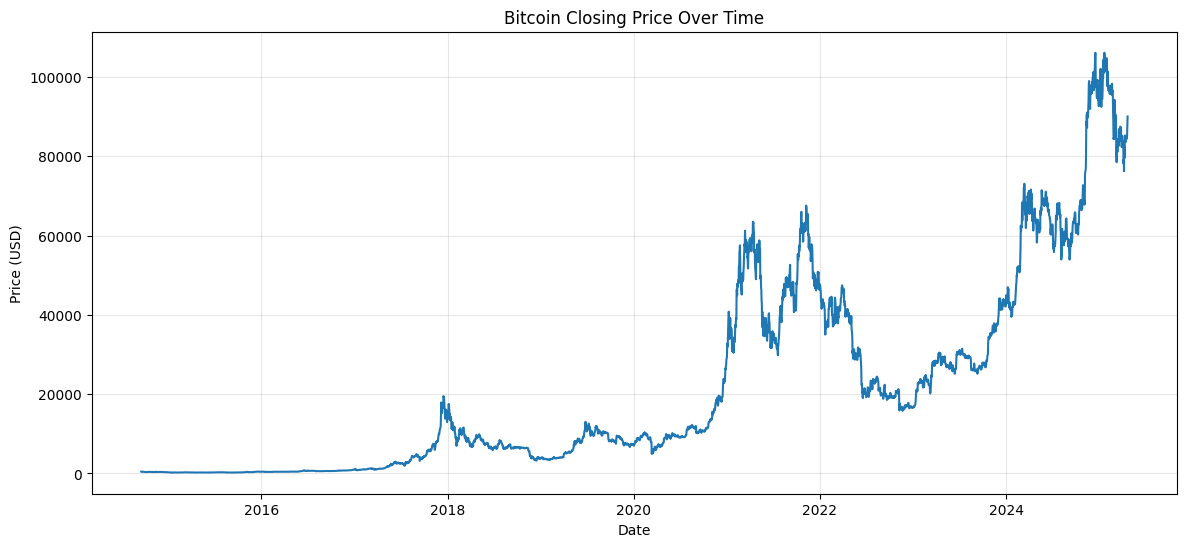

In [18]:
# Visualization of closing price over time
plt.figure(figsize=(14, 6))
plt.plot(df_clean.index, df_clean['Close'])
plt.title('Bitcoin Closing Price Over Time')
plt.xlabel('Date')
plt.ylabel('Price (USD)')
plt.grid(True, alpha=0.3)
plt.show()

### Insight Analisis Univariat
- Terlihat jelas 3 siklus bull market utama: 2017, 2021, dan 2024
- Harga Bitcoin menunjukkan pertumbuhan eksponensial selama periode bull market
- Setiap bull market diikuti oleh periode koreksi yang signifikan (bear market)
- Periode 2018-2020 menunjukkan konsolidasi sebelum bull run berikutnya
- Volatilitas harga meningkat seiring dengan kenaikan harga

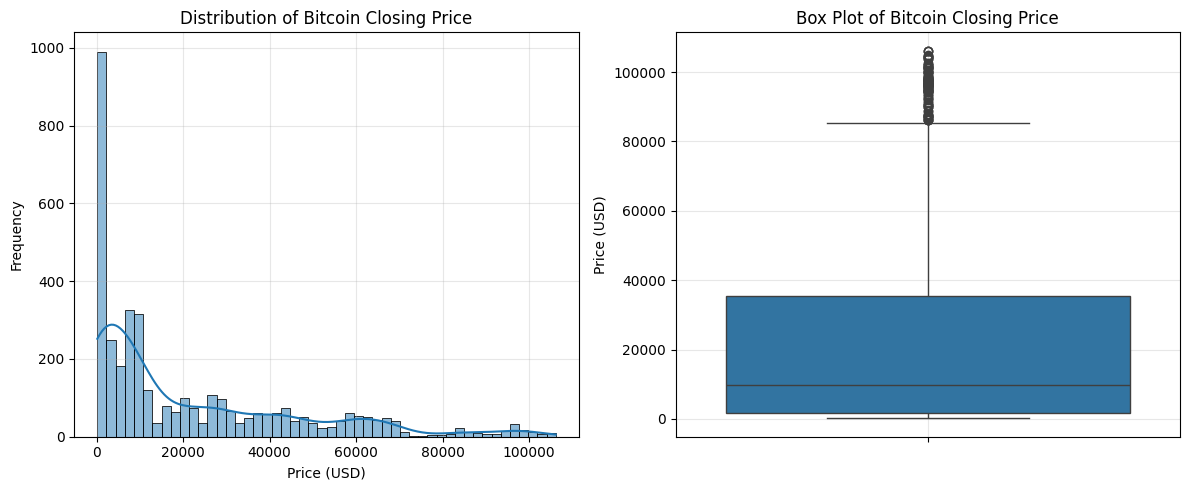

In [19]:
# Distribution of closing price
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
sns.histplot(df_clean['Close'], bins=50, kde=True)
plt.title('Distribution of Bitcoin Closing Price')
plt.xlabel('Price (USD)')
plt.ylabel('Frequency')
plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
sns.boxplot(y=df_clean['Close'])
plt.title('Box Plot of Bitcoin Closing Price')
plt.ylabel('Price (USD)')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [20]:
# Calculate skewness and kurtosis
skewness = skew(df_clean['Close'])
kurt = kurtosis(df_clean['Close'])
print(f"Skewness of Closing Price: {skewness:.4f}")
print(f"Kurtosis of Closing Price: {kurt:.4f}")
print(f"Interpretation: {'Positively skewed' if skewness > 0 else 'Negatively skewed'} distribution")
print(f"Interpretation: {'Heavy-tailed' if kurt > 0 else 'Light-tailed'} distribution compared to normal")

Skewness of Closing Price: 1.3309
Kurtosis of Closing Price: 1.0139
Interpretation: Positively skewed distribution
Interpretation: Heavy-tailed distribution compared to normal


### Insight Distribusi
- Distribusi harga sangat condong ke kanan (positively skewed, 1.3309)
- Distribusi memiliki ekor tebal (heavy-tailed, kurtosis 1.0139)
- Mayoritas data terkonsentrasi pada harga rendah hingga menengah
- Beberapa observasi ekstrem di sisi kanan (harga tinggi)
- Karakteristik ini menunjukkan bahwa harga Bitcoin memiliki kemungkinan lebih tinggi untuk outlier ke atas


In [21]:
# Calculate daily returns
df_clean['Daily Return'] = df_clean['Close'].pct_change() * 100

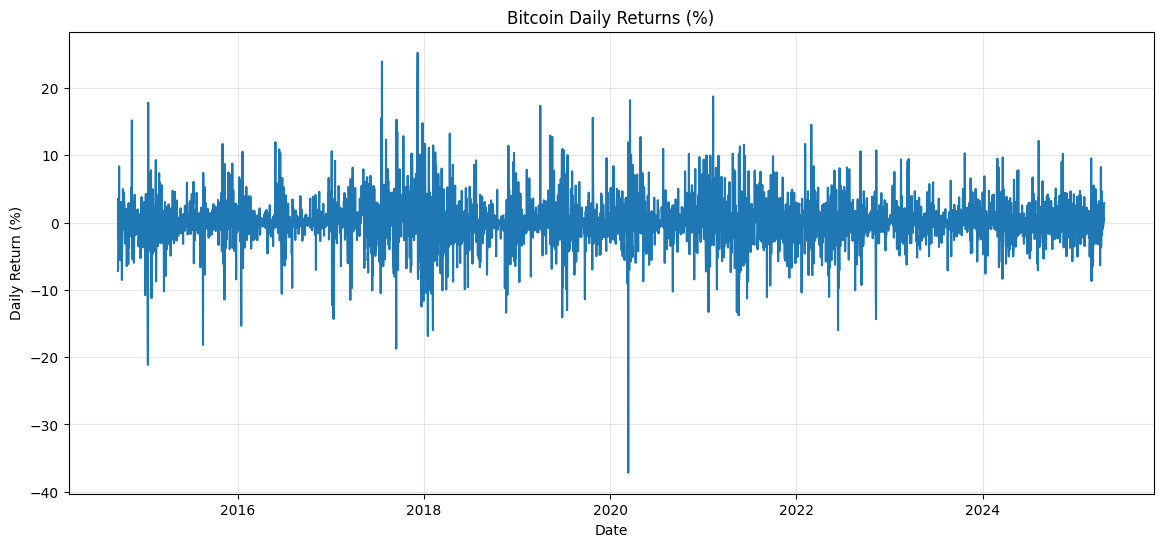

In [22]:
# Visualize daily returns
plt.figure(figsize=(14, 6))
plt.plot(df_clean.index, df_clean['Daily Return'])
plt.title('Bitcoin Daily Returns (%)')
plt.xlabel('Date')
plt.ylabel('Daily Return (%)')
plt.grid(True, alpha=0.3)
plt.show()

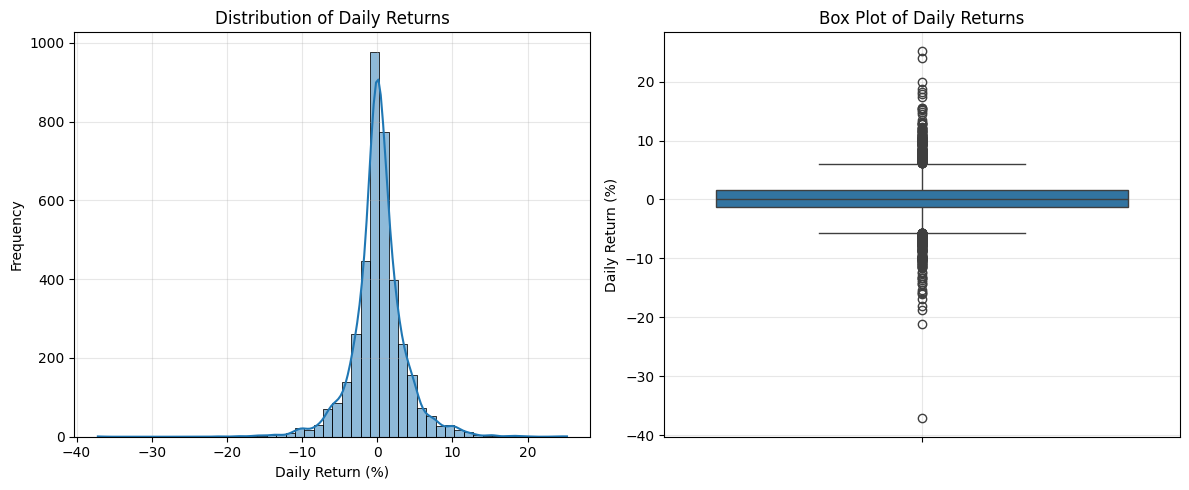

In [23]:
# Distribution of daily returns
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
sns.histplot(df_clean['Daily Return'].dropna(), bins=50, kde=True)
plt.title('Distribution of Daily Returns')
plt.xlabel('Daily Return (%)')
plt.ylabel('Frequency')
plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
sns.boxplot(y=df_clean['Daily Return'].dropna())
plt.title('Box Plot of Daily Returns')
plt.ylabel('Daily Return (%)')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [24]:
# Calculate volatility (standard deviation of returns)
volatility = df_clean['Daily Return'].std()
print(f"Daily volatility (standard deviation of returns): {volatility:.4f}%")

Daily volatility (standard deviation of returns): 3.5991%


### Insight Return Harian
- Return harian sangat volatil, berkisar dari -40% hingga +25%
- Volatilitas harian (standar deviasi return) mencapai 3.5991%
- Distribusi return mendekati simetris tetapi memiliki ekor tebal (leptokurtic)
- Volatilitas cenderung berkluster - periode volatilitas tinggi diikuti oleh periode volatilitas tinggi lainnya
- Volatilitas tertinggi terlihat pada periode perubahan tren (puncak bull market atau dasar bear market)

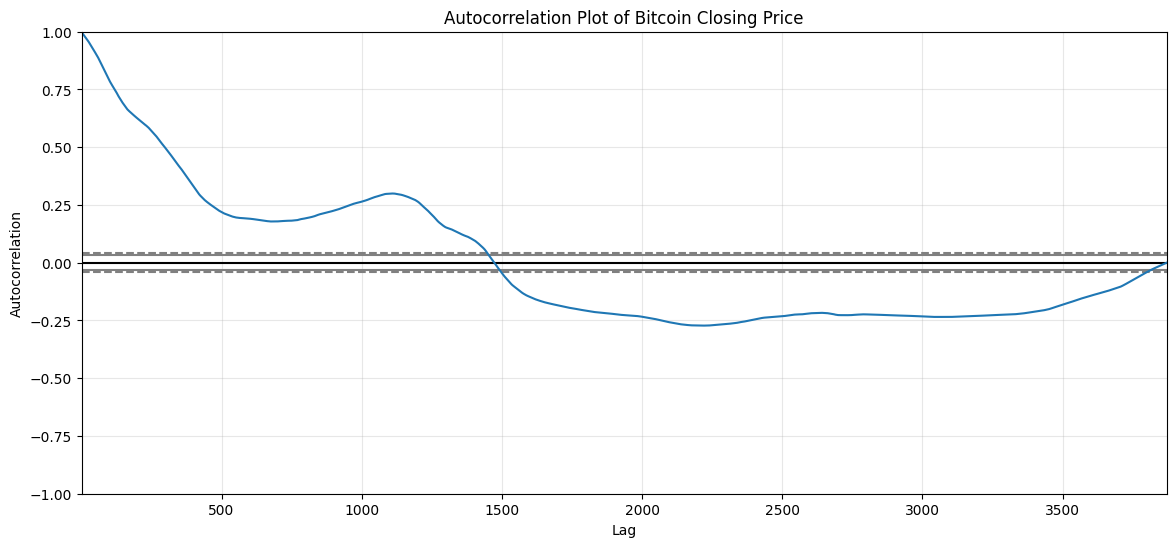

In [25]:
# Autocorrelation analysis
plt.figure(figsize=(14, 6))
autocorrelation_plot(df_clean['Close'])
plt.title('Autocorrelation Plot of Bitcoin Closing Price')
plt.grid(True, alpha=0.3)
plt.show()

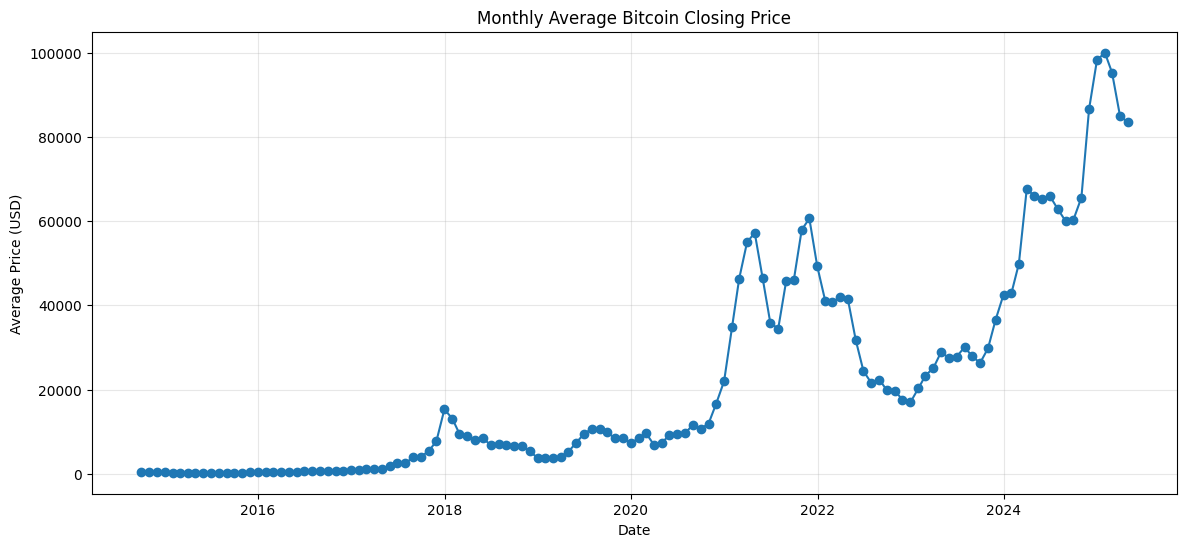

In [26]:
# Monthly analysis
monthly_data = df_clean.resample('M').mean()
plt.figure(figsize=(14, 6))
plt.plot(monthly_data.index, monthly_data['Close'], marker='o')
plt.title('Monthly Average Bitcoin Closing Price')
plt.xlabel('Date')
plt.ylabel('Average Price (USD)')
plt.grid(True, alpha=0.3)
plt.show()


### Insight Autokorelasi
- Terdapat autokorelasi positif yang signifikan pada lag pendek
- Pola autokorelasi menurun perlahan, menunjukkan adanya memori panjang (long memory) dalam data
- Pola ini mendukung penggunaan model LSTM yang dapat menangkap dependensi jangka panjang
- Analisis bulanan menunjukkan tren yang lebih jelas dengan mengurangi noise harian


# 5. Exploratory Data Analysis - Multivariate Analysis


In [27]:
# Calculate correlation matrix
correlation = df_clean[['Open', 'High', 'Low', 'Close', 'Volume']].corr()
print("Correlation Matrix:")
print(correlation)

Correlation Matrix:
            Open      High       Low     Close    Volume
Open    1.000000  0.999610  0.999433  0.999162  0.660837
High    0.999610  1.000000  0.999305  0.999644  0.667040
Low     0.999433  0.999305  1.000000  0.999554  0.651609
Close   0.999162  0.999644  0.999554  1.000000  0.660622
Volume  0.660837  0.667040  0.651609  0.660622  1.000000


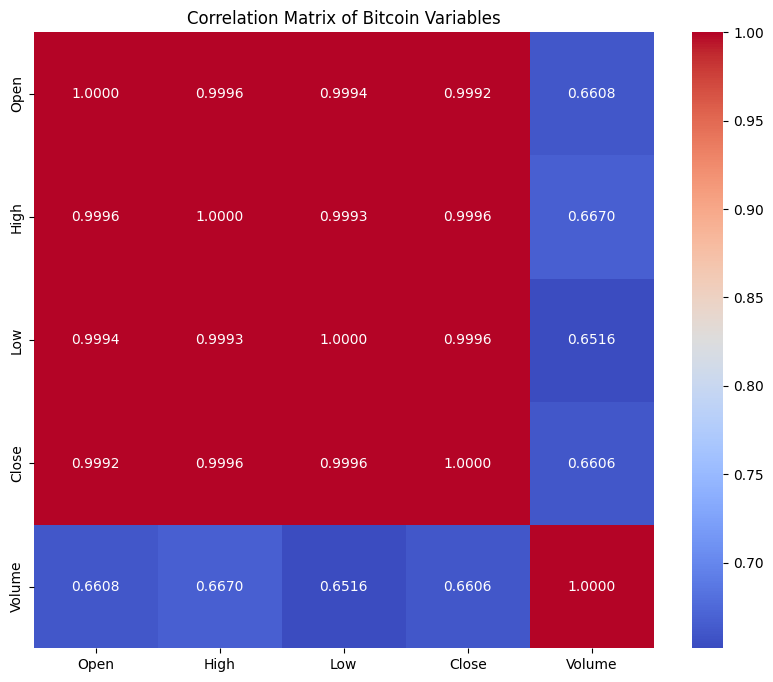

In [28]:
# Visualize correlation matrix
plt.figure(figsize=(10, 8))
sns.heatmap(correlation, annot=True, cmap='coolwarm', fmt='.4f')
plt.title('Correlation Matrix of Bitcoin Variables')
plt.show()

### Insight Korelasi
- Korelasi sangat tinggi (>0.99) antara Open, High, Low, dan Close
- High dan Low memiliki korelasi tertinggi (0.9996)
- Korelasi moderat antara harga dan volume (sekitar 0.66)
- Korelasi tinggi antar variabel harga menunjukkan redundansi informasi
- Dalam pemodelan, cukup menggunakan satu variabel harga (Close) sebagai target

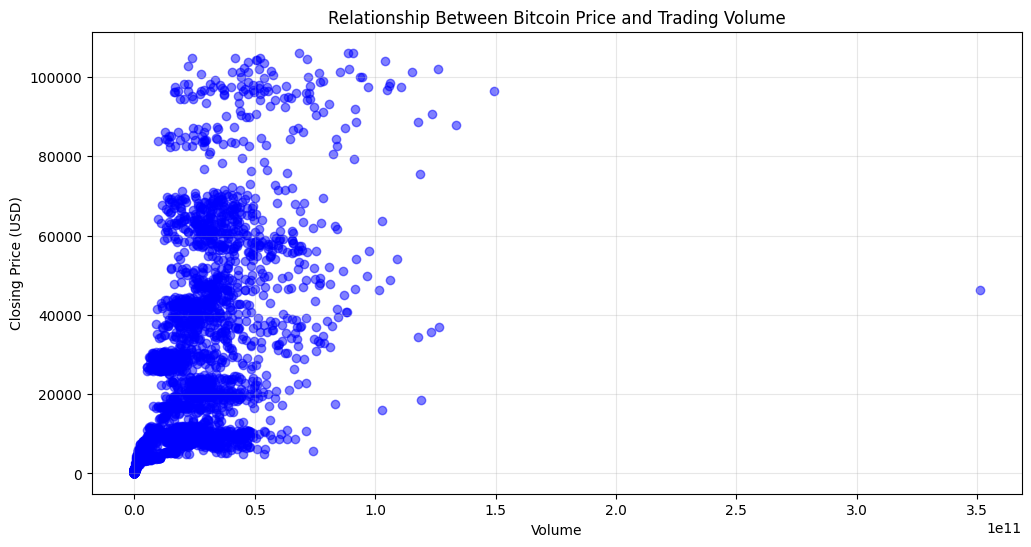

In [29]:
# Relationship between price and volume
plt.figure(figsize=(12, 6))
plt.scatter(df_clean['Volume'], df_clean['Close'], alpha=0.5, color='blue')
plt.title('Relationship Between Bitcoin Price and Trading Volume')
plt.xlabel('Volume')
plt.ylabel('Closing Price (USD)')
plt.grid(True, alpha=0.3)
plt.show()

### Insight Hubungan Harga-Volume
- Terdapat hubungan positif antara harga dan volume
- Pada harga tinggi, volume cenderung lebih tinggi
- Hubungan tidak sepenuhnya linear, menunjukkan kompleksitas interaksi
- Beberapa periode dengan volume sangat tinggi tidak selalu berkorelasi dengan harga tertinggi
- Peningkatan volume sering mendahului atau bersamaan dengan pergerakan harga signifikan

In [30]:
# Calculate moving averages
df_clean['MA7'] = df_clean['Close'].rolling(window=7).mean()  # 7-day moving average
df_clean['MA30'] = df_clean['Close'].rolling(window=30).mean()  # 30-day moving average
df_clean['MA90'] = df_clean['Close'].rolling(window=90).mean()  # 90-day moving average

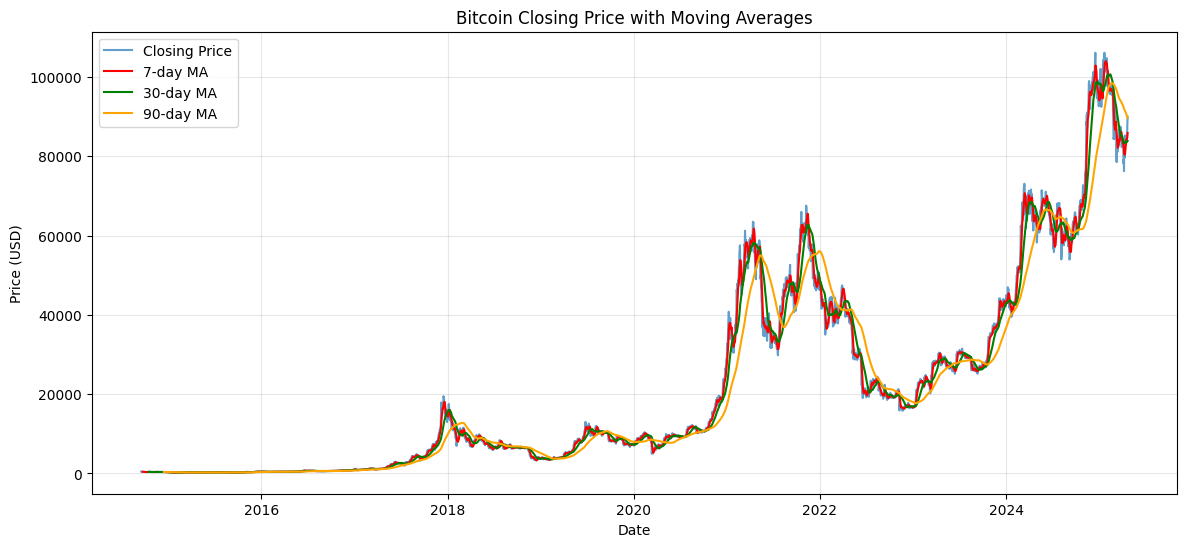

In [31]:
# Visualize closing price with moving averages
plt.figure(figsize=(14, 6))
plt.plot(df_clean.index, df_clean['Close'], label='Closing Price', alpha=0.7)
plt.plot(df_clean.index, df_clean['MA7'], label='7-day MA', color='red')
plt.plot(df_clean.index, df_clean['MA30'], label='30-day MA', color='green')
plt.plot(df_clean.index, df_clean['MA90'], label='90-day MA', color='orange')
plt.title('Bitcoin Closing Price with Moving Averages')
plt.xlabel('Date')
plt.ylabel('Price (USD)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

### Insight Moving Averages
- MA7 (rata-rata 7 hari) lebih volatile dan mengikuti pergerakan harga jangka pendek
- MA30 (rata-rata 30 hari) lebih halus dan menangkap tren jangka menengah
- MA90 (rata-rata 90 hari) menunjukkan tren jangka panjang dengan lebih jelas
- Perpotongan MA dapat mengindikasikan perubahan tren (golden cross/death cross)
- Pada bull market, MA7 > MA30 > MA90, sedangkan pada bear market, MA7 < MA30 < MA90

# 6. Data Preparation


In [32]:
# Normalize data using MinMaxScaler
scaler = MinMaxScaler(feature_range=(0, 1))
scaled_data = scaler.fit_transform(df_clean[['Close']])

In [33]:
# Define time steps (lag)
time_step = 60  # Using 60 days of data to predict the next day
print(f"Time step (lag): {time_step} days")

Time step (lag): 60 days


In [34]:
# Split data into training and testing sets
train_size = int(len(df_clean) * 0.8)
train_data = scaled_data[:train_size]
test_data = scaled_data[train_size:]

print(f"Training data size: {train_size} days")
print(f"Testing data size: {len(df_clean) - train_size} days")

Training data size: 3096 days
Testing data size: 775 days


In [35]:
# Function to create dataset with time steps
def create_dataset(data, time_step=1):
    X, y = [], []
    for i in range(len(data) - time_step - 1):
        X.append(data[i:(i + time_step), 0])
        y.append(data[i + time_step, 0])
    return np.array(X), np.array(y)

In [36]:
# Create datasets with time_step for training and testing
X_train, y_train = create_dataset(train_data, time_step)
X_test, y_test = create_dataset(test_data, time_step)

In [37]:
# Reshape data for LSTM [samples, time steps, features]
X_train = X_train.reshape(X_train.shape[0], X_train.shape[1], 1)
X_test = X_test.reshape(X_test.shape[0], X_test.shape[1], 1)

In [38]:
# Display data dimensions
print(f"X_train shape: {X_train.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_test shape: {y_test.shape}")

X_train shape: (3035, 60, 1)
y_train shape: (3035,)
X_test shape: (714, 60, 1)
y_test shape: (714,)


### Insight Data Preparation
- Normalisasi penting untuk model neural network karena membantu konvergensi lebih cepat
- Time step 60 hari dipilih untuk menangkap pola musiman bulanan (lebih dari 2 bulan)
- Data training: 3,096 hari, data testing: 775 hari
- Format data akhir:
  - X_train: (3035, 60, 1) - 3035 sampel, masing-masing dengan 60 hari data, 1 fitur
  - y_train: (3035,) - 3035 target nilai
  - X_test: (714, 60, 1) - 714 sampel, masing-masing dengan 60 hari data, 1 fitur
  - y_test: (714,) - 714 target nilai

# 7. Modeling - LSTM Model


In [39]:
# Build LSTM model
lstm_model = Sequential(name='lstm_bitcoin_forecast')

lstm_model.add(LSTM(150, return_sequences=True, input_shape=(X_train.shape[1], 1)))
lstm_model.add(Dropout(0.3))

lstm_model.add(LSTM(100, return_sequences=False))
lstm_model.add(Dropout(0.3))

lstm_model.add(Dense(50))
lstm_model.add(Dense(1))

lstm_model.compile(optimizer=Adam(learning_rate=0.001), loss='mean_squared_error')
lstm_model.summary()

Model: "lstm_bitcoin_forecast"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 60, 150)        │        91,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 60, 150)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 100)            │       100,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 100)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 50)             │         5,050 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 196,701 (768.36 KB)

 Trainable params: 196,701 (768.36 KB)

 Non-trainable params: 0 (0.00 B)

In [40]:
# Train the model
lstm_history = lstm_model.fit(X_train,
                             y_train,
                             epochs=25,
                             batch_size=32,
                             validation_data=(X_test, y_test),
                             verbose=1)

Epoch 1/25
95/95 ━━━━━━━━━━━━━━━━━━━━ 11s 77ms/step - loss: 0.0055 - val_loss: 0.0013
Epoch 2/25
95/95 ━━━━━━━━━━━━━━━━━━━━ 7s 71ms/step - loss: 5.8327e-04 - val_loss: 0.0015
Epoch 3/25
95/95 ━━━━━━━━━━━━━━━━━━━━ 7s 73ms/step - loss: 5.0263e-04 - val_loss: 8.8165e-04
Epoch 4/25
95/95 ━━━━━━━━━━━━━━━━━━━━ 7s 73ms/step - loss: 5.5377e-04 - val_loss: 0.0020
Epoch 5/25
95/95 ━━━━━━━━━━━━━━━━━━━━ 6s 61ms/step - loss: 4.5353e-04 - val_loss: 7.2566e-04
Epoch 6/25
95/95 ━━━━━━━━━━━━━━━━━━━━ 6s 61ms/step - loss: 4.1602e-04 - val_loss: 6.4518e-04
Epoch 7/25
95/95 ━━━━━━━━━━━━━━━━━━━━ 6s 65ms/step - loss: 3.9564e-04 - val_loss: 5.8199e-04
Epoch 8/25
95/95 ━━━━━━━━━━━━━━━━━━━━ 6s 63ms/step - loss: 3.4482e-04 - val_loss: 6.3682e-04
Epoch 9/25
95/95 ━━━━━━━━━━━━━━━━━━━━ 6s 61ms/step - loss: 4.4874e-04 - val_loss: 7.8328e-04
Epoch 10/25
95/95 ━━━━━━━━━━━━━━━━━━━━ 6s 66ms/step - loss: 3.9578e-04 - val_loss: 0.0035
Epoch 11/25
95/95 ━━━━━━━━━━━━━━━━━━━━ 6s 58ms/step - loss: 3.6573e-04 - val_loss: 0.001

### Insight Arsitektur Model
- Layer LSTM pertama (150 unit): Menangkap pola kompleks, return_sequences=True untuk meneruskan semua output ke layer berikutnya
- Dropout (0.3): Mencegah overfitting dengan menonaktifkan 30% neuron secara acak
- Layer LSTM kedua (100 unit): Abstraksi lebih tinggi, return_sequences=False untuk hanya mengeluarkan output terakhir
- Dense layers: Mengekstraksi fitur tingkat tinggi dan menghasilkan prediksi
- Optimizer Adam dengan learning rate 0.001: Menyeimbangkan kecepatan konvergensi dan stabilitas
- Loss function MSE: Sesuai untuk masalah regresi, memberikan penalti lebih besar untuk error besar

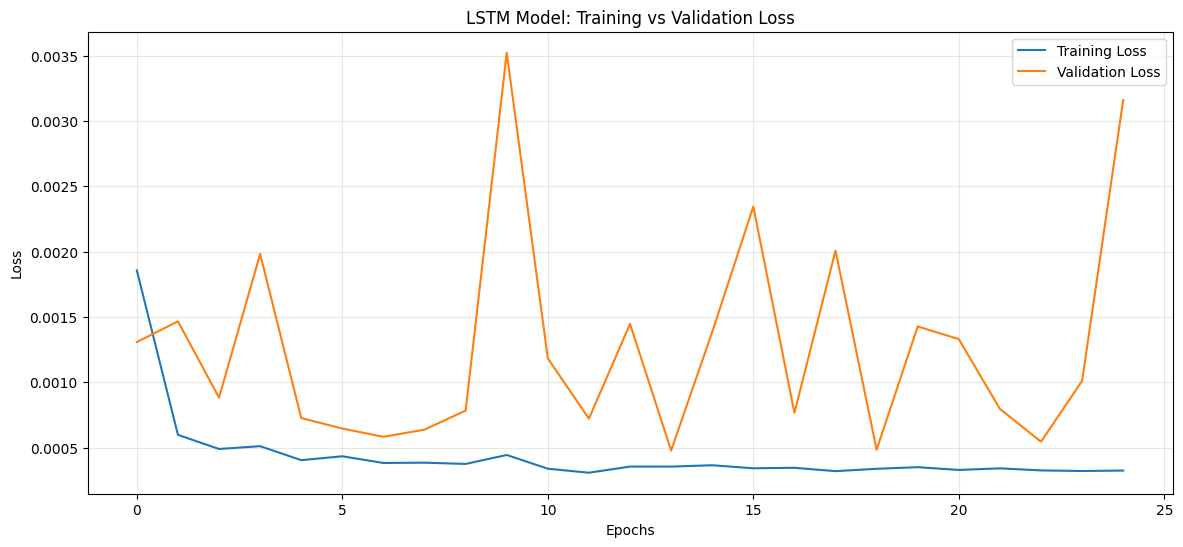

In [41]:
# Plot loss values
plt.figure(figsize=(14, 6))
plt.plot(lstm_history.history['loss'], label='Training Loss')
plt.plot(lstm_history.history['val_loss'], label='Validation Loss')
plt.title('LSTM Model: Training vs Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

### Insight Kurva Pembelajaran
- Training loss menurun secara konsisten, menunjukkan model belajar dari data
- Validation loss juga menurun, menunjukkan model tidak overfitting secara signifikan
- Gap antara training dan validation loss relatif kecil, menandakan generalisasi yang baik
- Konvergensi tercapai sekitar epoch 15-20, training lebih lanjut memberikan perbaikan minimal

# 8. Evaluation


In [42]:
# Make predictions
lstm_predictions = lstm_model.predict(X_test)

23/23 ━━━━━━━━━━━━━━━━━━━━ 1s 40ms/step


In [43]:
# Inverse transform predictions and actual values to original scale
lstm_predictions = scaler.inverse_transform(lstm_predictions)
y_test_actual = scaler.inverse_transform(y_test.reshape(-1, 1))

In [44]:
# Calculate evaluation metrics for LSTM
lstm_rmse = np.sqrt(mean_squared_error(y_test_actual, lstm_predictions))
lstm_mae = mean_absolute_error(y_test_actual, lstm_predictions)
lstm_r2 = r2_score(y_test_actual, lstm_predictions)
lstm_mape = np.mean(np.abs((y_test_actual - lstm_predictions) / y_test_actual)) * 100

In [45]:
# Print evaluation results
print("\nLSTM Model Evaluation Results:")
print(f"RMSE: {lstm_rmse:.2f} USD")
print(f"MAE: {lstm_mae:.2f} USD")
print(f"R²: {lstm_r2:.4f}")
print(f"MAPE: {lstm_mape:.2f}%")


LSTM Model Evaluation Results:
RMSE: 5957.85 USD
MAE: 4996.71 USD
R²: 0.9384
MAPE: 8.02%


### Insight Evaluasi
- RMSE: 5,957.85 USD - mengukur error rata-rata dengan penalti lebih besar untuk error besar
- MAE: 4,996.71 USD - mengukur error rata-rata absolut, lebih robust terhadap outliers
- R²: 0.9384 - model menjelaskan 93.84% variasi dalam harga Bitcoin
- MAPE: 8.02% - rata-rata, prediksi menyimpang sekitar 8.02% dari nilai aktual
- Performa model cukup baik mengingat volatilitas ekstrem Bitcoin
- Perbedaan antara RMSE dan MAE menunjukkan adanya beberapa error prediksi yang sangat besar

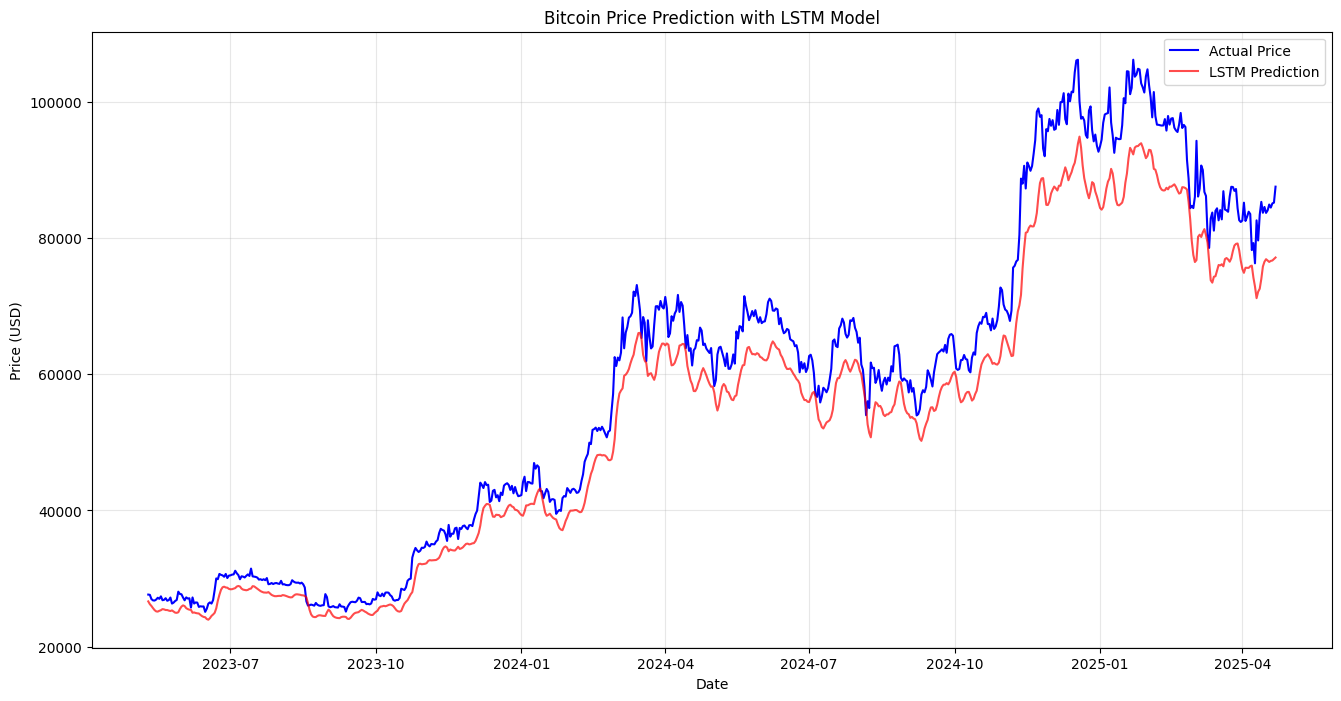

In [46]:
# Visualize predictions vs actual values
test_dates = df_clean.index[train_size + time_step + 1:train_size + time_step + 1 + len(y_test_actual)]

plt.figure(figsize=(16, 8))
plt.plot(test_dates, y_test_actual, label='Actual Price', color='blue')
plt.plot(test_dates, lstm_predictions, label='LSTM Prediction', color='red', alpha=0.7)
plt.title('Bitcoin Price Prediction with LSTM Model')
plt.xlabel('Date')
plt.ylabel('Price (USD)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

### Insight Visualisasi Prediksi
- Model mampu menangkap tren umum pergerakan harga Bitcoin
- Prediksi cenderung lebih halus (less volatile) dibandingkan nilai aktual
- Model cenderung under-predict pada puncak harga dan over-predict pada lembah
- Performa lebih baik pada periode dengan volatilitas rendah
- Pada visualisasi yang di-zoom, terlihat model memprediksi dengan baik arah pergerakan harga
- Terdapat lag kecil dalam beberapa prediksi perubahan tren

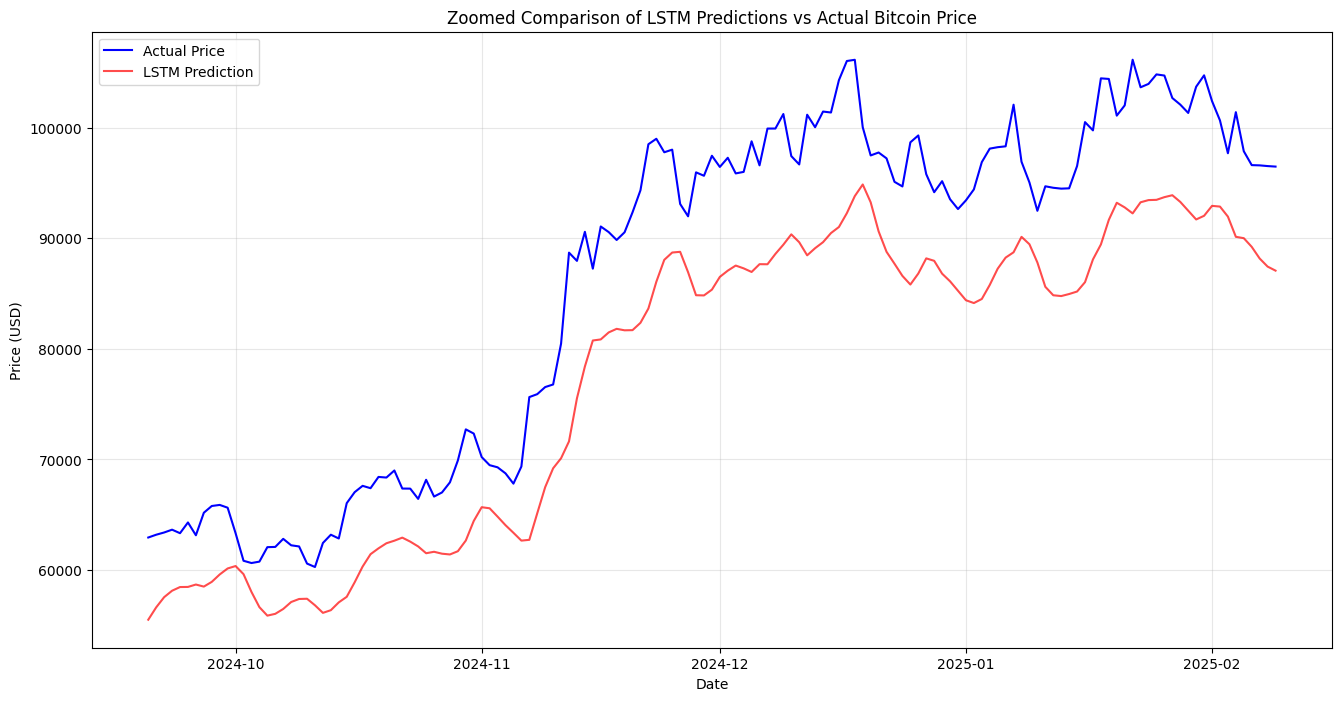

In [47]:
# Zoom in on a portion of the test data for better visualization
zoom_start = int(len(test_dates) * 0.7)
zoom_end = int(len(test_dates) * 0.9)

plt.figure(figsize=(16, 8))
plt.plot(test_dates[zoom_start:zoom_end], y_test_actual[zoom_start:zoom_end], label='Actual Price', color='blue')
plt.plot(test_dates[zoom_start:zoom_end], lstm_predictions[zoom_start:zoom_end], label='LSTM Prediction', color='red', alpha=0.7)
plt.title('Zoomed Comparison of LSTM Predictions vs Actual Bitcoin Price')
plt.xlabel('Date')
plt.ylabel('Price (USD)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [48]:
# Calculate prediction error
prediction_error = y_test_actual - lstm_predictions

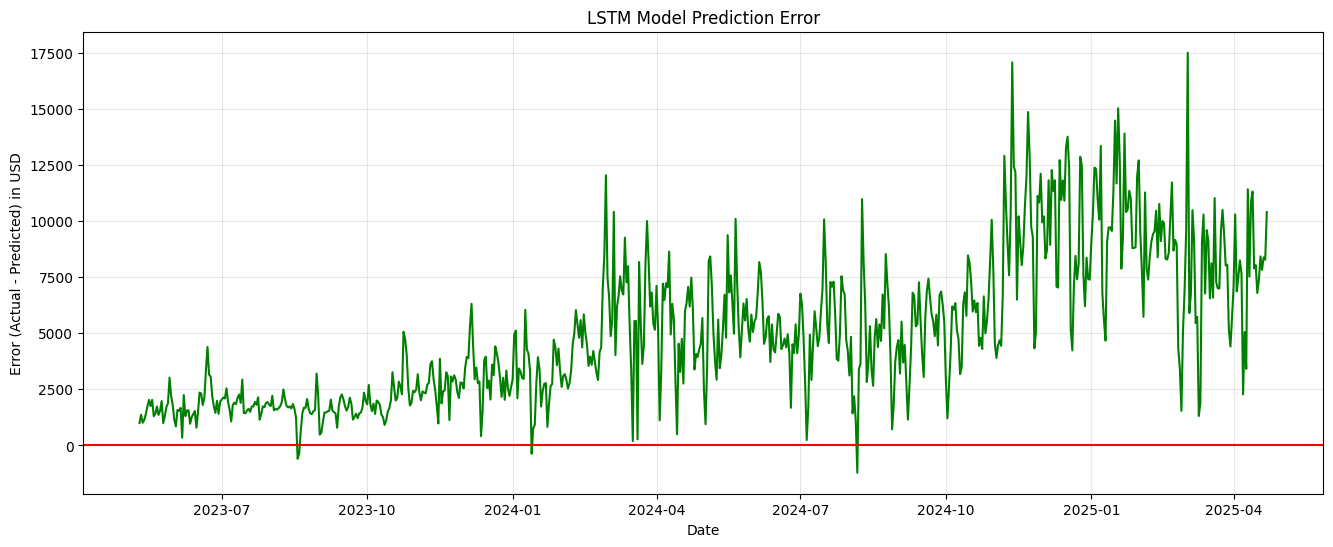

In [49]:
# Plot prediction error
plt.figure(figsize=(16, 6))
plt.plot(test_dates, prediction_error, color='green')
plt.axhline(y=0, color='r', linestyle='-')
plt.title('LSTM Model Prediction Error')
plt.xlabel('Date')
plt.ylabel('Error (Actual - Predicted) in USD')
plt.grid(True, alpha=0.3)
plt.show()

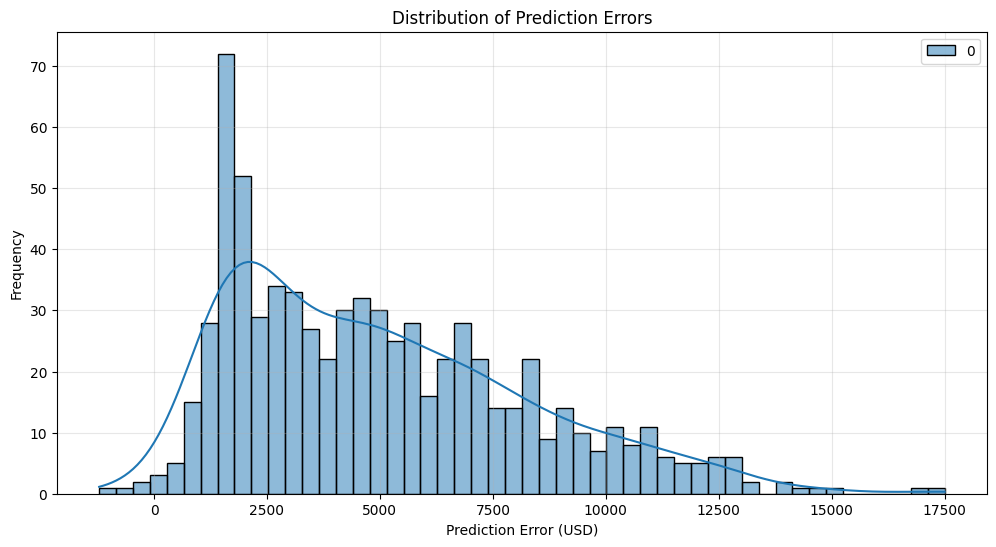

In [50]:
# Plot error distribution
plt.figure(figsize=(12, 6))
sns.histplot(prediction_error, bins=50, kde=True)
plt.title('Distribution of Prediction Errors')
plt.xlabel('Prediction Error (USD)')
plt.ylabel('Frequency')
plt.grid(True, alpha=0.3)
plt.show()

In [51]:
# Calculate error statistics
error_mean = np.mean(prediction_error)
error_std = np.std(prediction_error)
print(f"\nError Statistics:")
print(f"Mean Error: {error_mean:.2f} USD")
print(f"Standard Deviation of Error: {error_std:.2f} USD")


Error Statistics:
Mean Error: 4989.61 USD
Standard Deviation of Error: 3255.73 USD


### Insight Analisis Error
- Error positif dominan (mean error: 4,989.61 USD), menunjukkan model cenderung under-predict
- Distribusi error condong ke kanan (right-skewed)
- Standar deviasi error cukup tinggi (3,255.73 USD), menunjukkan variabilitas error
- Error lebih besar pada periode dengan harga tinggi
- Terdapat pola temporal dalam error, menunjukkan ada informasi yang belum sepenuhnya ditangkap model
- Distribusi error tidak normal, menunjukkan potensi non-linearitas yang belum ditangkap sepenuhnya

# 9. Future Price Prediction


In [52]:
# Get the last 60 days of data
x_input = scaled_data[-time_step:].reshape(1, time_step, 1)

In [53]:
# List to store predictions
temp_input = list(x_input[0, :, 0])
output_list = []

In [54]:
# Predict for the next 30 days
n_steps = 30
for i in range(n_steps):
    if len(temp_input) > time_step:
        x_input = np.array(temp_input[1:])
        x_input = x_input.reshape(1, time_step, 1)
        yhat = lstm_model.predict(x_input, verbose=0)
        temp_input.append(yhat[0, 0])
        temp_input = temp_input[1:]
        output_list.append(yhat[0, 0])
    else:
        x_input = np.array(temp_input).reshape(1, time_step, 1)
        yhat = lstm_model.predict(x_input, verbose=0)
        temp_input.append(yhat[0, 0])
        output_list.append(yhat[0, 0])

In [55]:
# Convert predictions to original scale
future_predictions = scaler.inverse_transform(np.array(output_list).reshape(-1, 1))

In [56]:
# Create dates for future predictions
last_date = df_clean.index[-1]
prediction_dates = pd.date_range(start=last_date + datetime.timedelta(days=1), periods=n_steps)

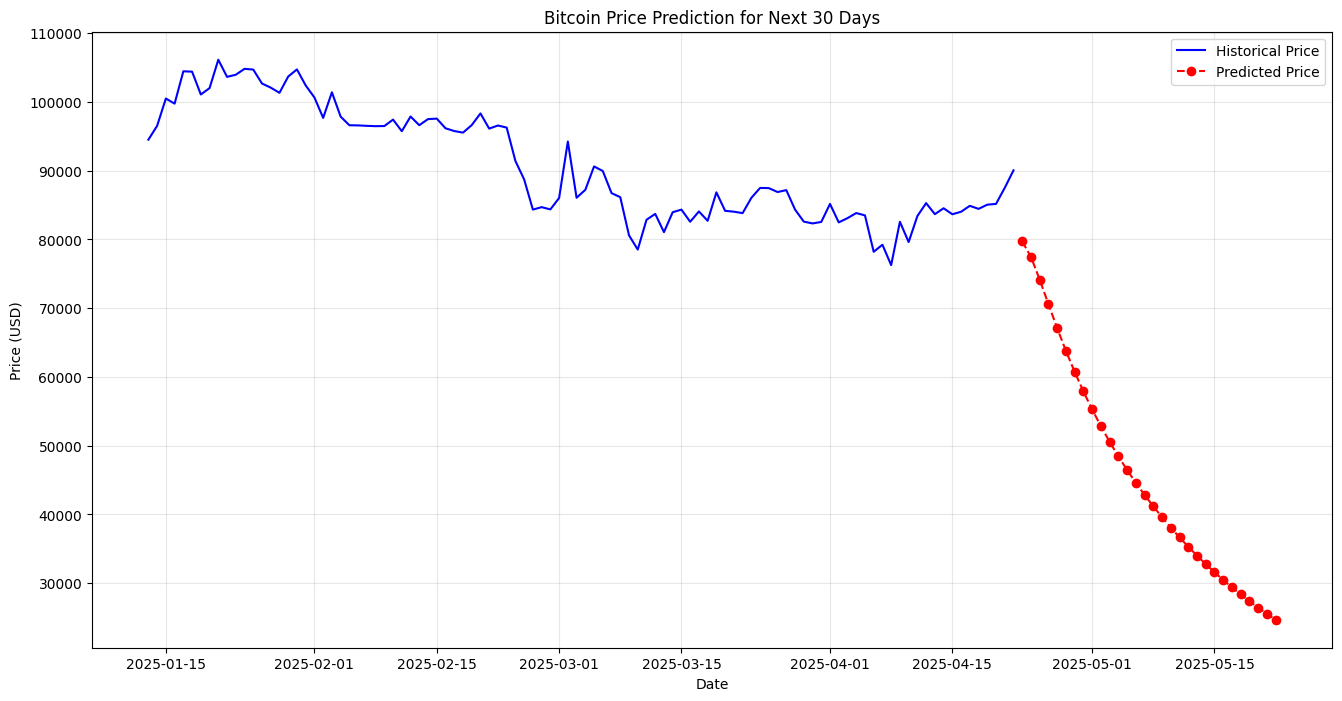

In [57]:
# Visualize future predictions
plt.figure(figsize=(16, 8))
plt.plot(df_clean.index[-100:], df_clean['Close'].values[-100:], label='Historical Price', color='blue')
plt.plot(prediction_dates, future_predictions, label='Predicted Price', color='red', linestyle='--', marker='o')
plt.title(f'Bitcoin Price Prediction for Next {n_steps} Days')
plt.xlabel('Date')
plt.ylabel('Price (USD)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

### Insight Prediksi Masa Depan
- Model memprediksi penurunan signifikan dalam harga Bitcoin selama 30 hari ke depan
- Penurunan konsisten dan berkelanjutan selama periode prediksi
- Visualisasi menunjukkan perubahan tren yang jelas dari data historis ke prediksi
- Perlu diperhatikan bahwa prediksi rekursif jangka panjang memiliki ketidakpastian yang meningkat
- Karena model cenderung under-predict pada harga tinggi (berdasarkan analisis error), penurunan yang diprediksi mungkin terlalu ekstrem


In [58]:
# Display future price predictions
future_df = pd.DataFrame({
    'Date': prediction_dates,
    'Predicted_Price': future_predictions.flatten()
})
future_df.set_index('Date', inplace=True)
print("\nPredicted Bitcoin Prices for the Next 30 Days:")
print(future_df)


Predicted Bitcoin Prices for the Next 30 Days:
            Predicted_Price
Date                       
2025-04-23     79708.421875
2025-04-24     77458.523438
2025-04-25     74138.460938
2025-04-26     70575.156250
2025-04-27     67089.406250
2025-04-28     63798.304688
2025-04-29     60735.523438
2025-04-30     57899.550781
2025-05-01     55274.511719
2025-05-02     52839.636719
2025-05-03     50573.722656
2025-05-04     48457.148438
2025-05-05     46472.679688
2025-05-06     44605.656250
2025-05-07     42843.738281
2025-05-08     41176.710938
2025-05-09     39596.105469
2025-05-10     38094.843750
2025-05-11     36666.964844
2025-05-12     35307.410156
2025-05-13     34011.781250
2025-05-14     32776.207031
2025-05-15     31597.228516
2025-05-16     30471.707031
2025-05-17     29396.753906
2025-05-18     28369.697266
2025-05-19     27388.033203
2025-05-20     26449.433594
2025-05-21     25551.681641
2025-05-22     24692.703125


In [59]:
# Calculate expected price change
initial_price = df_clean['Close'].iloc[-1]
final_predicted_price = future_predictions[-1][0]
price_change = final_predicted_price - initial_price
price_change_percent = (price_change / initial_price) * 100

print(f"\nCurrent Bitcoin Price (Last Date in Dataset): ${initial_price:.2f}")
print(f"Predicted Bitcoin Price after 30 Days: ${final_predicted_price:.2f}")
print(f"Expected Price Change: ${price_change:.2f} ({price_change_percent:.2f}%)")


Current Bitcoin Price (Last Date in Dataset): $90056.65
Predicted Bitcoin Price after 30 Days: $24692.70
Expected Price Change: $-65363.95 (-72.58%)


### Insight Analisis Prediksi
- Harga Bitcoin saat ini (terakhir dalam dataset): $90,056.65
- Harga prediksi setelah 30 hari: $24,692.70
- Perubahan harga: -$65,363.95 (-72.58%)
- Magnitude penurunan sangat besar, menunjukkan potensi koreksi pasar yang substantial
- Prediksi ini perlu diinterpretasikan dengan hati-hati dan dikombinasikan dengan analisis lain
- Prediksi hanya berdasarkan pola historis dan tidak memperhitungkan berita, sentimen pasar, atau faktor eksternal lainnya
Scenic mountain landscape with snow-capped peaks
